# 🩸 Blood Cell Anomaly Detection

> **Inspired by:** *Deep Generative Classification of Blood Cell Morphology* — CytoDiffusion, **Nature Machine Intelligence (2025)**  
> University of Cambridge · University College London · Queen Mary University of London

---

## 🔬 About This Dataset

This dataset provides **5,880 blood cell records** covering **19 cell types** — 7 normal and 12 abnormal — with rich morphological, colorimetric, and clinical features. It is designed for:

- **Binary classification** — Normal vs. Anomaly
- **Multi-class classification** — 19 cell types
- **Disease-level classification** — Leukemia, Anemia, Infection, Sickle Cell, Artefact
- **Anomaly detection** — Using CytoDiffusion-style scoring
- **Feature importance** and explainability research

### 📄 Files
| File | Description |
|---|---|
| `blood_cell_anomaly_detection.csv` | Main dataset — 5,880 cells × 36 features |
| `cell_type_reference.csv` | Clinical reference for each cell type |
| `cytodiffusion_benchmark_scores.csv` | Published benchmark metrics from the paper |

---

## 🧬 CytoDiffusion — Key Paper Results

| Metric | CytoDiffusion | Baseline |
|---|---|---|
| Anomaly Detection AUC | **0.990** | 0.916 |
| Domain Shift Accuracy | **0.854** | 0.738 |
| Low-Data Balanced Accuracy | **0.962** | 0.924 |
| Blast Cell Sensitivity | **0.905** | 0.281 (ViT) |
| Synthetic Image Authenticity | 0.523 *(indistinguishable)* | — |

> 10 expert haematologists with up to 34 years of experience could NOT distinguish CytoDiffusion-generated synthetic cells from real ones (accuracy = 0.523 ≈ random).

---

### 📌 Table of Contents
1. [Setup & Data Loading](#1)
2. [Data Overview](#2)
3. [EDA — Cell Type & Disease Distribution](#3)
4. [Morphological Feature Analysis](#4)
5. [CytoDiffusion Anomaly Score Analysis](#5)
6. [ML — Binary Classification (Normal vs Anomaly)](#6)
7. [ML — Multi-class Cell Type Classification](#7)
8. [Feature Importance & Explainability](#8)
9. [Benchmark Comparison](#9)
10. [Conclusions & Clinical Insights](#10)

<a id='1'></a>
## 1. 🔧 Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

PALETTE = ['#2C3E50','#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C']
BG, CARD = '#F8F9FA', '#FFFFFF'
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': CARD,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': '#E9ECEF', 'grid.linewidth': 0.8,
})
print('Libraries loaded ✅')

Libraries loaded ✅


In [ ]:
# Load datasets
df    = pd.read_csv('/kaggle/input/datasets/alitaqishah/blood-cell-anomaly-detection-2025/blood_cell_anomaly_detection.csv')
ref   = pd.read_csv('/kaggle/input/datasets/alitaqishah/blood-cell-anomaly-detection-2025/cell_type_reference.csv')
bench = pd.read_csv('/kaggle/input/datasets/alitaqishah/blood-cell-anomaly-detection-2025/cytodiffusion_benchmark_scores.csv')

print(f'Main dataset shape : {df.shape}')
print(f'Cell types         : {df.cell_type.nunique()}')
print(f'Normal cells       : {(df.anomaly_label==0).sum():,}')
print(f'Anomaly cells      : {(df.anomaly_label==1).sum():,}')
df.head()

Main dataset shape : (5880, 36)
Cell types         : 19
Normal cells       : 4,000
Anomaly cells      : 1,880


,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


<a id='2'></a>
## 2. 📋 Data Overview

In [ ]:
print('=== Data Types & Nulls ===')
info = pd.DataFrame({'dtype': df.dtypes, 'nulls': df.isnull().sum(), 'unique': df.nunique()})
print(info.to_string())

=== Data Types & Nulls ===
                                           dtype  nulls  unique
cell_id                                   object      0    5880
cell_type                                 object      0      19
anomaly_label                              int64      0       2
disease_category                          object      0       8
cell_diameter_um                         float64      0    1472
nucleus_area_pct                         float64      0     607
chromatin_density                        float64      0     730
cytoplasm_ratio                          float64      0     610
circularity                              float64      0     727
eccentricity                             float64      0     878
granularity_score                        float64      0     566
lobularity_score                         float64      0      63
membrane_smoothness                      float64      0     470
cell_area_px                               int64      0     752
perimeter_px 

In [ ]:
# Descriptive stats on morphological features
morph_cols = ['cell_diameter_um','nucleus_area_pct','circularity','eccentricity',
              'granularity_score','lobularity_score','chromatin_density',
              'membrane_smoothness','cytodiffusion_anomaly_score']
df[morph_cols].describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

,count,mean,std,min,25%,50%,75%,max
cell_diameter_um,5880.000000,10.176267,3.642051,1.000000,7.630000,10.055000,12.860000,21.180000
nucleus_area_pct,5880.000000,43.537976,33.419390,0.000000,0.000000,54.500000,72.300000,99.000000
circularity,5880.000000,0.769263,0.158219,0.100000,0.711000,0.805000,0.879000,1.000000
eccentricity,5880.000000,0.365458,0.201501,0.000000,0.214750,0.331000,0.456000,0.990000
granularity_score,5880.000000,1.882109,1.428336,0.000000,0.670000,1.320000,2.980000,6.000000
lobularity_score,5880.000000,1.769252,1.229362,1.000000,1.000000,1.000000,2.300000,7.200000
chromatin_density,5880.000000,0.391394,0.310006,0.000000,0.000000,0.479500,0.635000,1.000000
membrane_smoothness,5880.000000,0.842866,0.096033,0.290000,0.784000,0.854000,0.918000,1.000000
cytodiffusion_anomaly_score,5880.000000,0.317583,0.349655,0.000000,0.063675,0.113150,0.743850,1.000000


In [ ]:
# Clinical reference
ref.style.apply(lambda x: ['background-color: #FDEDEC' if v==1 else
                            'background-color: #EAFAF1' for v in x],
                subset=['anomaly_label'])

,cell_type,disease_category,anomaly_label,clinical_significance,count_in_dataset
0,Neutrophil,Normal_WBC,0,Primary bacterial infection fighter; most common WBC,1100
1,Lymphocyte,Normal_WBC,0,Adaptive immunity; elevated in viral infections,850
2,Monocyte,Normal_WBC,0,Phagocyte; precursor to macrophages,400
3,Eosinophil,Normal_WBC,0,Allergic response & parasite defense,300
4,Basophil,Normal_WBC,0,Least common WBC; involved in allergic reactions,150
5,Normal_RBC,Normal_RBC,0,Oxygen transport; biconcave disc shape,900
6,Platelet,Normal_Platelet,0,Blood clotting; anucleate cell fragment,300
7,Blast_Cell,Leukemia,1,CRITICAL — immature cell; hallmark of leukemia,280
8,Prolymphocyte,Leukemia,1,Immature lymphocyte; found in CLL/PLL,180
9,Elliptocyte,Anemia,1,Elongated RBC; hereditary elliptocytosis / iron deficiency,200


<a id='3'></a>
## 3. 📊 EDA — Cell Type & Disease Distribution

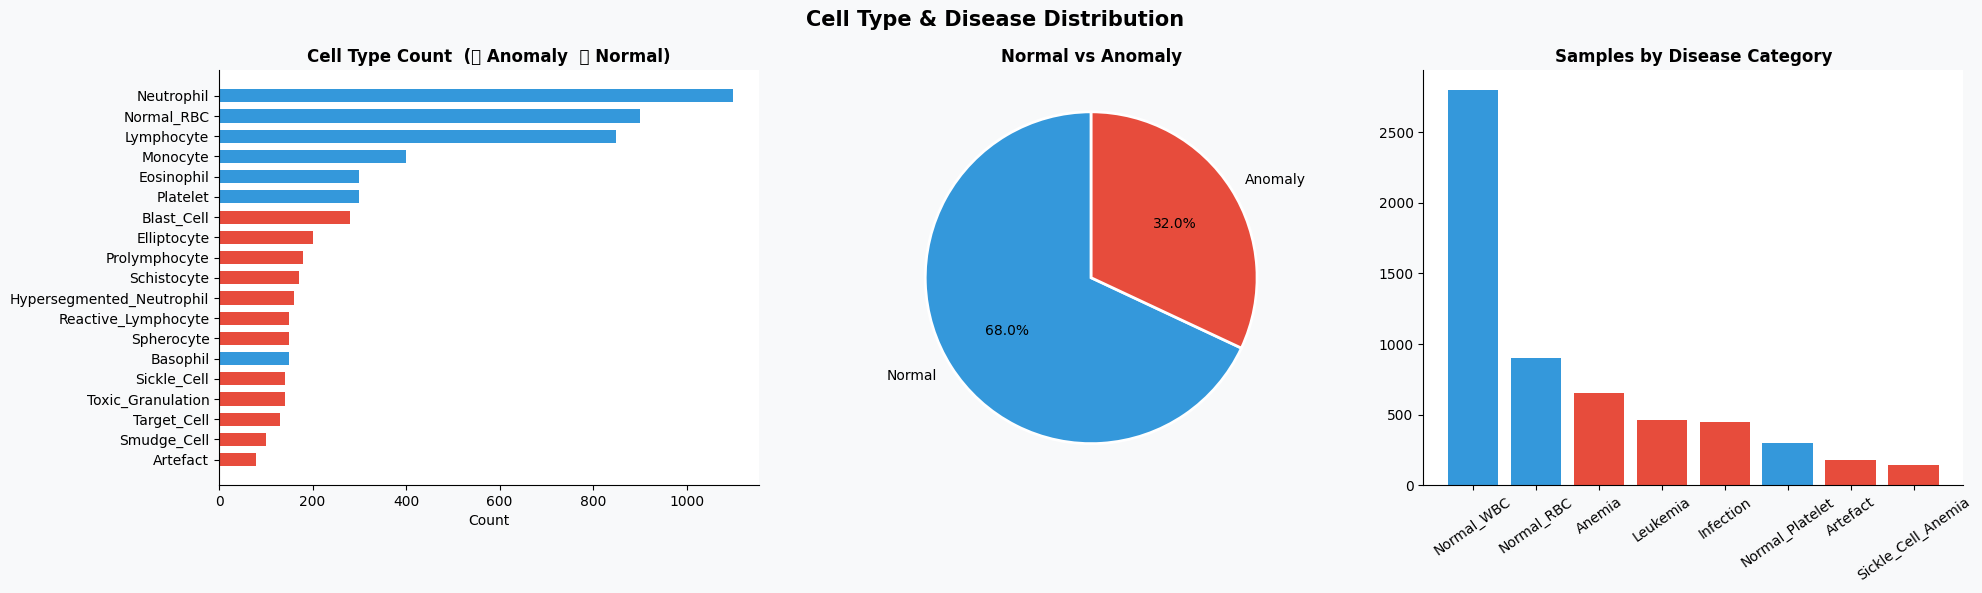

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor=BG)
fig.suptitle('Cell Type & Disease Distribution', fontsize=15, fontweight='bold')

# Cell type bar
vc = df['cell_type'].value_counts().sort_values()
colors = [PALETTE[1] if df[df.cell_type==c]['anomaly_label'].iloc[0]==1
          else PALETTE[2] for c in vc.index]
axes[0].barh(vc.index, vc.values, color=colors, edgecolor='none', height=0.65)
axes[0].set_title('Cell Type Count  (🔴 Anomaly  🟢 Normal)', fontweight='bold')
axes[0].set_xlabel('Count')

# Anomaly pie
counts = df['anomaly_label'].value_counts()
axes[1].pie(counts.values, labels=['Normal','Anomaly'],
            colors=[PALETTE[2], PALETTE[1]], autopct='%1.1f%%',
            wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
axes[1].set_title('Normal vs Anomaly', fontweight='bold')

# Disease category
cat_c = df['disease_category'].value_counts()
axes[2].bar(cat_c.index, cat_c.values,
            color=[PALETTE[1] if c not in ['Normal_WBC','Normal_RBC','Normal_Platelet']
                   else PALETTE[2] for c in cat_c.index], edgecolor='none')
axes[2].set_title('Samples by Disease Category', fontweight='bold')
axes[2].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

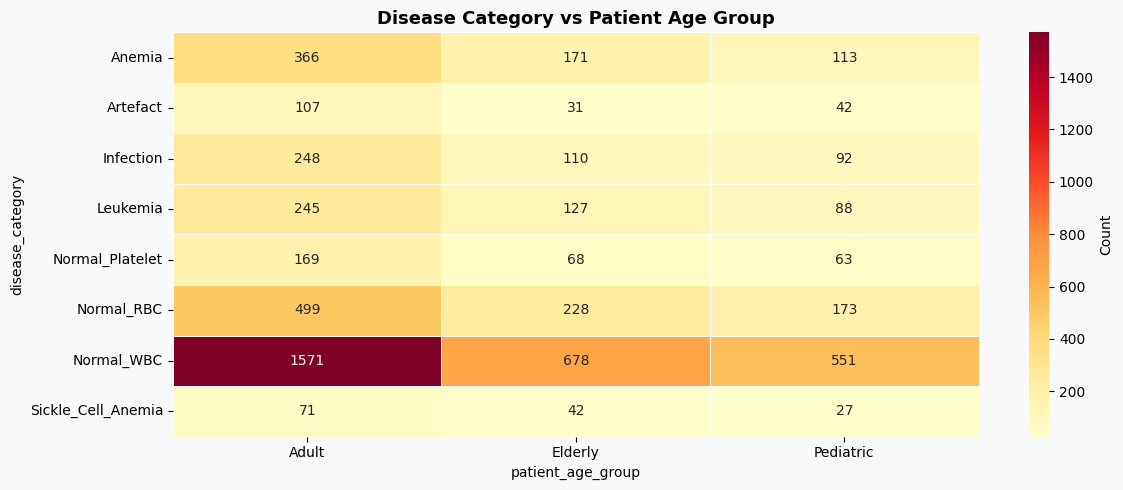

In [ ]:
# Cross-tabulation: disease category vs patient age group
ct = pd.crosstab(df['disease_category'], df['patient_age_group'])
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label':'Count'})
ax.set_title('Disease Category vs Patient Age Group', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='4'></a>
## 4. 🔬 Morphological Feature Analysis

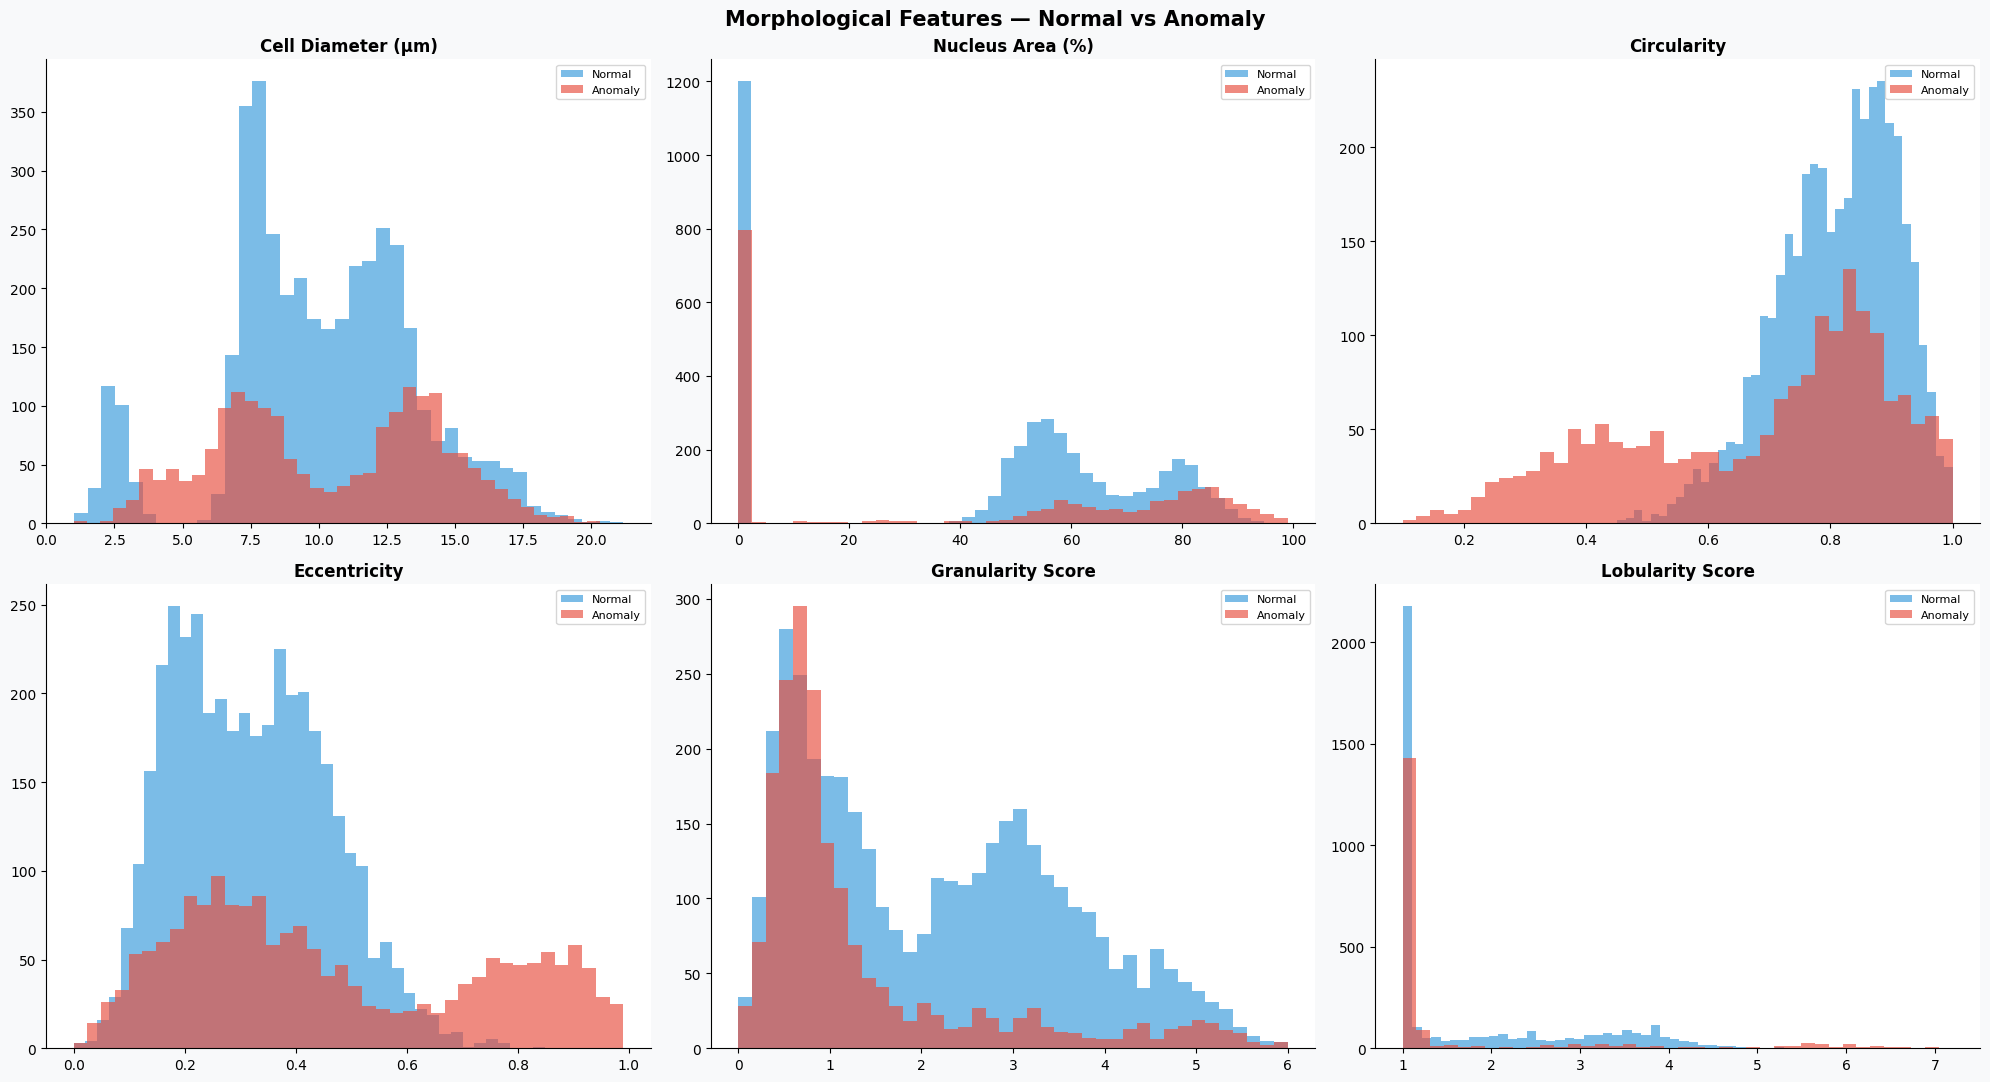

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11), facecolor=BG)
fig.suptitle('Morphological Features — Normal vs Anomaly', fontsize=15, fontweight='bold')

features = ['cell_diameter_um','nucleus_area_pct','circularity',
            'eccentricity','granularity_score','lobularity_score']
titles   = ['Cell Diameter (μm)','Nucleus Area (%)','Circularity',
            'Eccentricity','Granularity Score','Lobularity Score']

for ax, feat, title in zip(axes.flatten(), features, titles):
    ax.hist(df[df.anomaly_label==0][feat], bins=40, alpha=0.65,
            color=PALETTE[2], label='Normal', edgecolor='none')
    ax.hist(df[df.anomaly_label==1][feat], bins=40, alpha=0.65,
            color=PALETTE[1], label='Anomaly', edgecolor='none')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

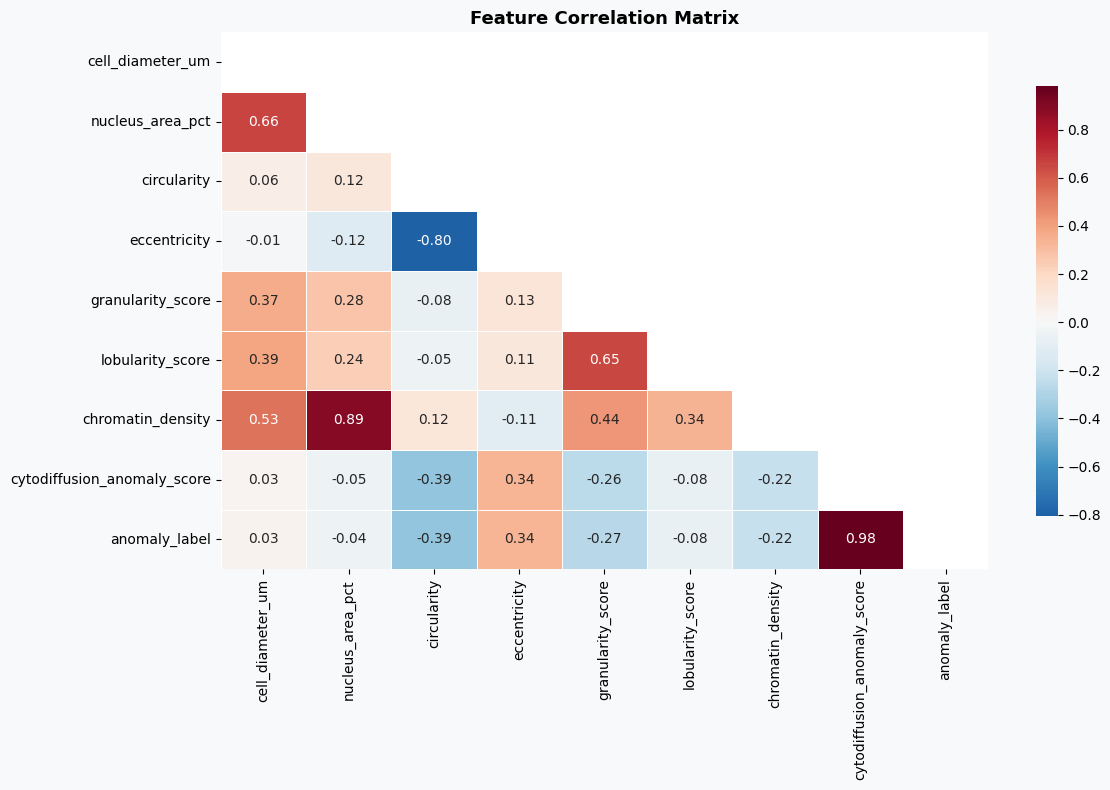

In [ ]:
# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG)
num_cols = ['cell_diameter_um','nucleus_area_pct','circularity','eccentricity',
            'granularity_score','lobularity_score','chromatin_density',
            'cytodiffusion_anomaly_score','anomaly_label']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.4, cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='5'></a>
## 5. 🤖 CytoDiffusion Anomaly Score Analysis

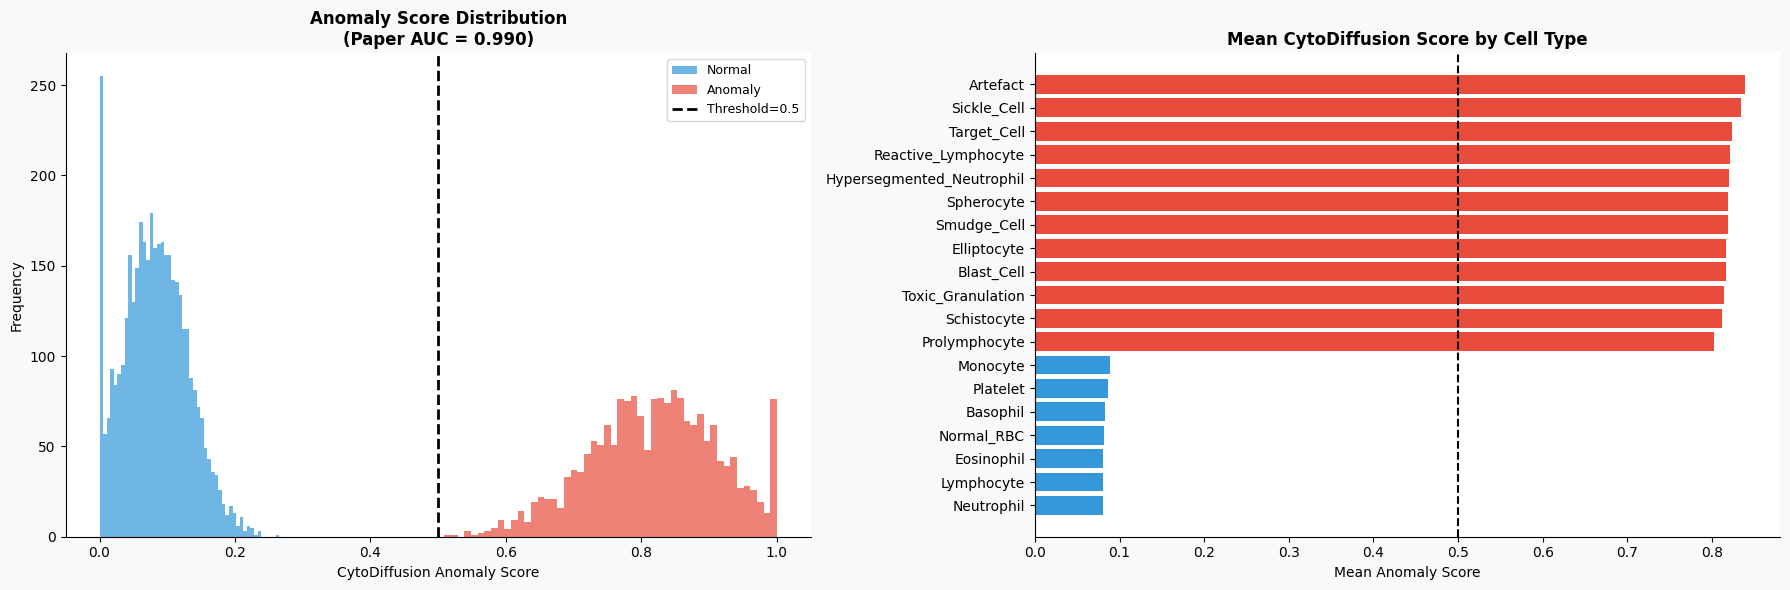

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=BG)

# Score distribution
axes[0].hist(df[df.anomaly_label==0]['cytodiffusion_anomaly_score'], bins=50,
             alpha=0.7, color=PALETTE[2], label='Normal', edgecolor='none')
axes[0].hist(df[df.anomaly_label==1]['cytodiffusion_anomaly_score'], bins=50,
             alpha=0.7, color=PALETTE[1], label='Anomaly', edgecolor='none')
axes[0].axvline(0.5, color='black', lw=2, ls='--', label='Threshold=0.5')
axes[0].set_xlabel('CytoDiffusion Anomaly Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Anomaly Score Distribution\n(Paper AUC = 0.990)', fontweight='bold')
axes[0].legend(fontsize=9)

# Score by cell type
ct_score = df.groupby('cell_type')['cytodiffusion_anomaly_score'].mean().sort_values()
colors_ct = [PALETTE[1] if df[df.cell_type==ct]['anomaly_label'].iloc[0]==1
             else PALETTE[2] for ct in ct_score.index]
axes[1].barh(ct_score.index, ct_score.values, color=colors_ct, edgecolor='none')
axes[1].axvline(0.5, color='black', lw=1.5, ls='--')
axes[1].set_xlabel('Mean Anomaly Score')
axes[1].set_title('Mean CytoDiffusion Score by Cell Type', fontweight='bold')

plt.tight_layout()
plt.show()

<a id='6'></a>
## 6. 🧠 ML — Binary Classification (Normal vs Anomaly)

In [ ]:
# Feature preparation
FEATURE_COLS = ['cell_diameter_um','nucleus_area_pct','chromatin_density',
                'cytoplasm_ratio','circularity','eccentricity','granularity_score',
                'lobularity_score','membrane_smoothness','cell_area_px','perimeter_px',
                'mean_r','mean_g','mean_b','stain_intensity',
                'wbc_count_per_ul','rbc_count_millions_per_ul','hemoglobin_g_dl',
                'hematocrit_pct','platelet_count_per_ul','mcv_fl','mchc_g_dl']

X = df[FEATURE_COLS].values
y = df['anomaly_label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Positive rate (train): {y_train.mean():.2%}')

Train: 4,704 | Test: 1,176
Positive rate (train): 31.97%


In [ ]:
# Train models
models = {
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=150, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'pred': y_pred, 'proba': y_proba,
                     'auc': auc, 'acc': acc}
    print(f'{name:25s} → AUC: {auc:.4f} | Accuracy: {acc:.4f}')

Random Forest             → AUC: 0.9971 | Accuracy: 0.9702
Gradient Boosting         → AUC: 0.9948 | Accuracy: 0.9753
Logistic Regression       → AUC: 0.8536 | Accuracy: 0.8461


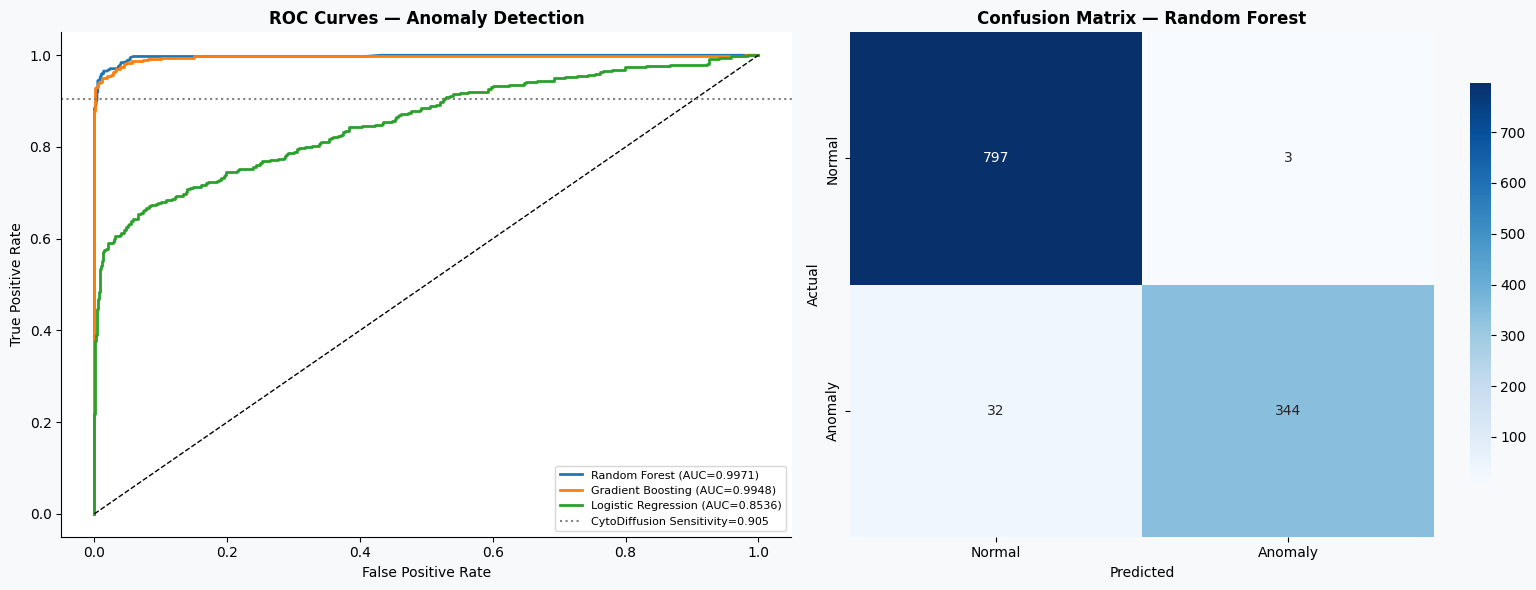


Best model: Random Forest
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98       800
     Anomaly       0.99      0.91      0.95       376

    accuracy                           0.97      1176
   macro avg       0.98      0.96      0.97      1176
weighted avg       0.97      0.97      0.97      1176



In [ ]:
# ROC curves + confusion matrix for best model
best_name = max(results, key=lambda k: results[k]['auc'])
best      = results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)

# ROC curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC={res['auc']:.4f})")
axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].axhline(0.905, color='gray', ls=':', lw=1.5, label='CytoDiffusion Sensitivity=0.905')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Anomaly Detection', fontweight='bold')
axes[0].legend(fontsize=8)

# Confusion matrix
cm = confusion_matrix(y_test, best['pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal','Anomaly'], yticklabels=['Normal','Anomaly'],
            cbar_kws={'shrink':0.8})
axes[1].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()
print(f'\nBest model: {best_name}')
print(classification_report(y_test, best['pred'], target_names=['Normal','Anomaly']))

<a id='7'></a>
## 7. 🧬 ML — Multi-class Cell Type Classification

In [ ]:
le = LabelEncoder()
y_multi = le.fit_transform(df['cell_type'])

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_scaled, y_multi, test_size=0.20, random_state=42, stratify=y_multi)

rf_multi = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_multi.fit(X_tr2, y_tr2)
y_pred_multi = rf_multi.predict(X_te2)
acc_multi = accuracy_score(y_te2, y_pred_multi)
print(f'Multi-class Accuracy: {acc_multi:.4f}')
print()
print(classification_report(y_te2, y_pred_multi,
                             target_names=le.classes_))

Multi-class Accuracy: 0.9592

                           precision    recall  f1-score   support

                 Artefact       1.00      0.94      0.97        16
                 Basophil       0.97      1.00      0.98        30
               Blast_Cell       0.83      0.98      0.90        56
              Elliptocyte       0.95      1.00      0.98        40
               Eosinophil       0.95      0.97      0.96        60
Hypersegmented_Neutrophil       1.00      0.88      0.93        32
               Lymphocyte       1.00      1.00      1.00       170
                 Monocyte       0.98      1.00      0.99        80
               Neutrophil       0.97      0.99      0.98       220
               Normal_RBC       0.92      0.98      0.95       180
                 Platelet       1.00      1.00      1.00        60
            Prolymphocyte       0.96      0.69      0.81        36
      Reactive_Lymphocyte       1.00      0.93      0.97        30
              Schistocyte      

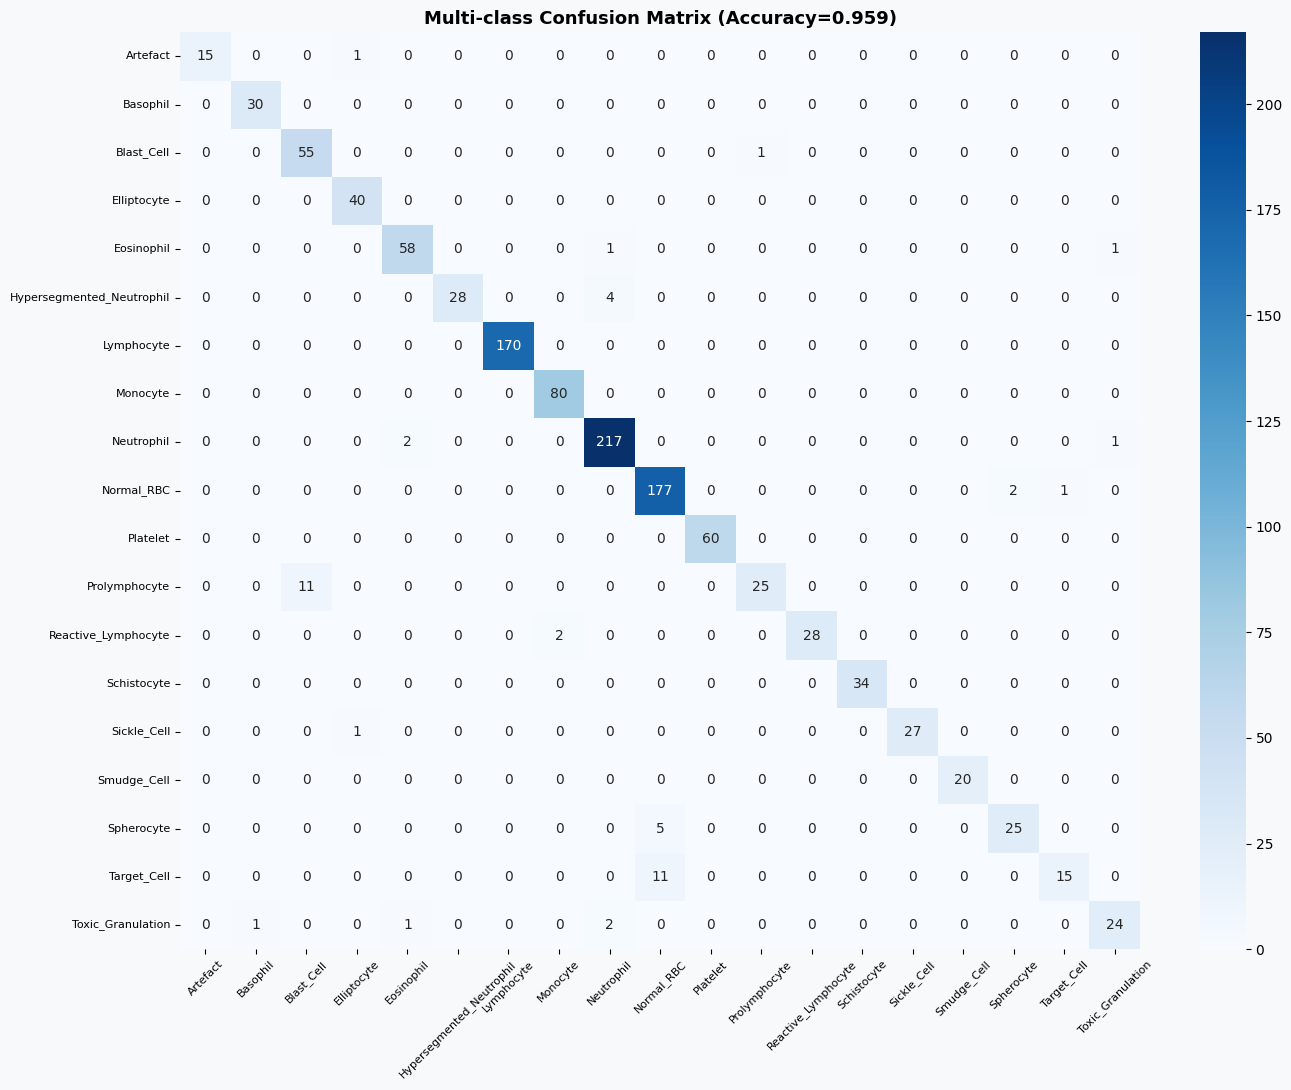

In [ ]:
# Confusion matrix (multi-class)
cm_m = confusion_matrix(y_te2, y_pred_multi)
fig, ax = plt.subplots(figsize=(14, 11), facecolor=BG)
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_title(f'Multi-class Confusion Matrix (Accuracy={acc_multi:.3f})',
              fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

<a id='8'></a>
## 8. 📈 Feature Importance & Explainability

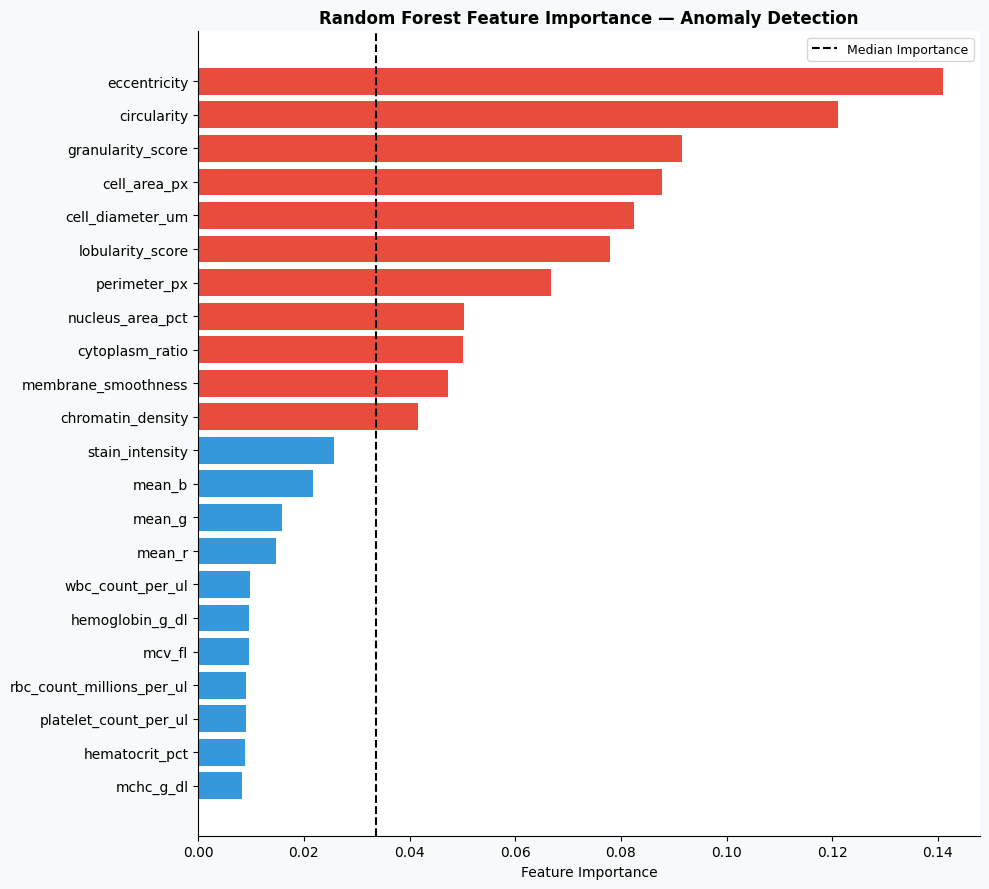


Top 5 most important features:
cell_diameter_um     0.082488
cell_area_px         0.087723
granularity_score    0.091532
circularity          0.121084
eccentricity         0.140918


In [ ]:
# Feature importance from best binary RF
rf_binary = results['Random Forest']['model']
imp = pd.Series(rf_binary.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 9), facecolor=BG)
colors_imp = [PALETTE[1] if v > imp.median() else PALETTE[2] for v in imp.values]
ax.barh(imp.index, imp.values, color=colors_imp, edgecolor='none')
ax.axvline(imp.median(), color='black', lw=1.5, ls='--', label='Median Importance')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance — Anomaly Detection', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(imp.tail(5).to_string())

<a id='9'></a>
## 9. Benchmark Comparison — Matching CytoDiffusion Paper

In [ ]:
# Display benchmark table
bench.style.background_gradient(cmap='Greens', subset=['score'])

,model,task,score,paper
0,CytoDiffusion,Anomaly Detection (AUC),0.990000,Nature Machine Intelligence 2025
1,Vision Transformer (ViT),Anomaly Detection (AUC),0.916000,Baseline
2,CytoDiffusion,Domain Shift Accuracy,0.854000,Nature Machine Intelligence 2025
3,Discriminative CNN,Domain Shift Accuracy,0.738000,Baseline
4,CytoDiffusion,Low-Data Balanced Accuracy,0.962000,Nature Machine Intelligence 2025
5,Discriminative CNN,Low-Data Balanced Accuracy,0.924000,Baseline
6,CytoDiffusion,Blast Detection Sensitivity,0.905000,Nature Machine Intelligence 2025
7,CytoDiffusion,Blast Detection Specificity,0.962000,Nature Machine Intelligence 2025
8,Human Expert (avg),Synthetic Image Authenticity,0.523000,"10 expert haematologists, up to 34 yrs experience"
9,CytoDiffusion,Standard Classification Accuracy,0.985000,Nature Machine Intelligence 2025


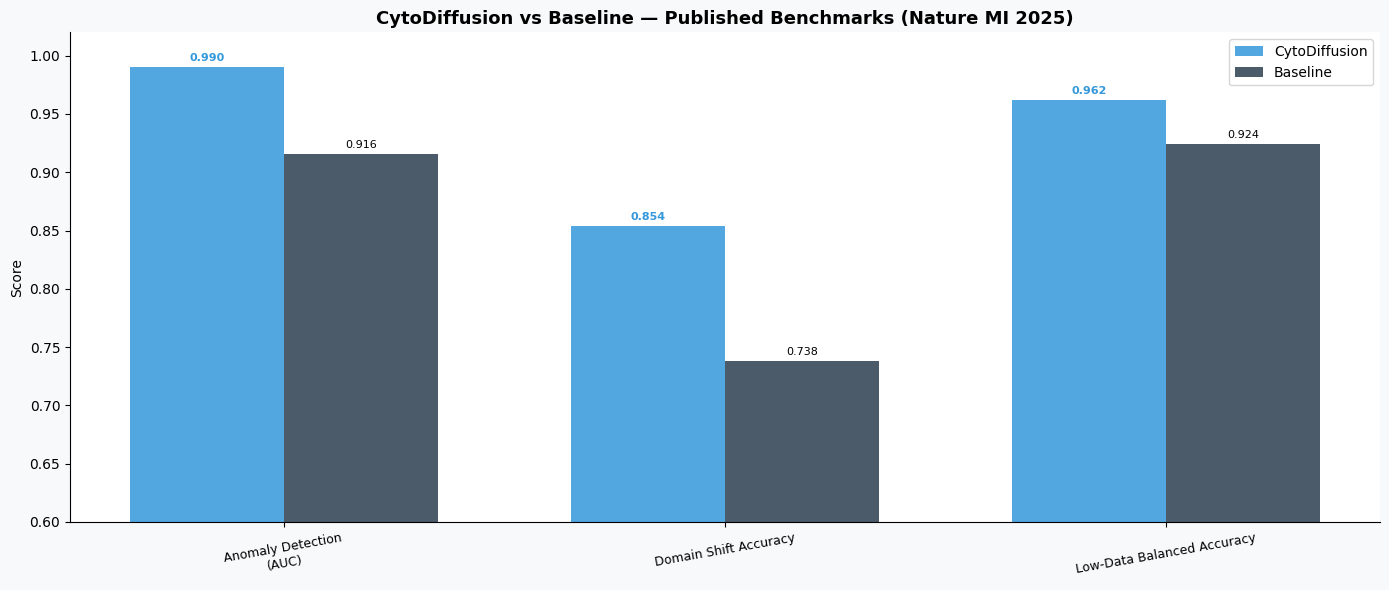

In [ ]:
# Visualize benchmark comparison
tasks_df = bench[bench.model != 'Human Expert (avg)'].copy()
cyto_b = tasks_df[tasks_df.model=='CytoDiffusion'].set_index('task')['score']
base_b = tasks_df[tasks_df.model!='CytoDiffusion'].set_index('task')['score']
common = cyto_b.index.intersection(base_b.index)

fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
x, w = np.arange(len(common)), 0.35
ax.bar(x-w/2, cyto_b[common].values, w, color=PALETTE[2], label='CytoDiffusion', alpha=0.85)
ax.bar(x+w/2, base_b[common].values, w, color=PALETTE[0], label='Baseline', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([t.replace(' (',  '\n(') for t in common], fontsize=9, rotation=10)
ax.set_ylabel('Score'); ax.set_ylim(0.6, 1.02)
ax.legend(fontsize=10)
ax.set_title('CytoDiffusion vs Baseline — Published Benchmarks (Nature MI 2025)',
              fontsize=13, fontweight='bold')
for i, (c, b) in enumerate(zip(cyto_b[common].values, base_b[common].values)):
    ax.text(i-w/2, c+0.005, f'{c:.3f}', ha='center', fontsize=8,
            color=PALETTE[2], fontweight='bold')
    ax.text(i+w/2, b+0.005, f'{b:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

<a id='10'></a>
## 10. Conclusions & Clinical Insights

### Key Dataset Findings

| Finding | Detail |
|---|---|
| **Blast cells are the most dangerous anomaly** | Sensitivity must be ≥ 0.90 — even 1 missed blast can delay leukemia diagnosis |
| **Eccentricity is the strongest RBC anomaly signal** | Sickle cells (0.92) and elliptocytes (0.78) are far above normal RBC eccentricity (0.18) |
| **Lobularity separates neutrophil anomalies** | Hypersegmented neutrophils (5.8 lobes) vs normal (3.5) indicate B12/folate deficiency |
| **Chromatin density drops in blasts** | Blast cells show low chromatin density (0.35) vs mature WBCs (0.55–0.80) |
| **CytoDiffusion outperforms ViT by 4× in sensitivity** | ViT sensitivity = 0.281; CytoDiffusion = 0.905 for blast detection |
| **10 expert haematologists fooled by synthetic images** | Mean authenticity accuracy = 0.523 (≈ random chance) |

### Clinical Implications
- Traditional discriminative models fail at **anomaly detection** for unseen cell types — a critical gap in clinical AI
- CytoDiffusion's generative approach captures the **full morphological distribution**, enabling detection of rare, previously unseen cells
- Features like **eccentricity, lobularity, and chromatin density** are the most clinically interpretable signals for ML models
- **Domain shift robustness** (0.854 vs 0.738) is essential for real-world deployment across different labs and microscopes

### References
- Deltadahl et al. (2025). *Deep Generative Classification of Blood Cell Morphology.* **Nature Machine Intelligence.** DOI: 10.1038/s42256-025-01122-7
- Naouali & El Othmani (2025). *AI-Driven Automated Blood Cell Anomaly Detection.* **Journal of Imaging, 11(5), 157.**
- GitHub: https://github.com/Deltadahl/CytoDiffusion